# Assignment 1 — Unsupervised Learning Methods
## Task 5: Clustering — Hierarchical Clustering
**Dataset:** Heart Disease UCI — `processed.cleveland.data`  
**Goal:** Apply hierarchical clustering to the preprocessed patient data, compare
two linkage methods, select an optimal number of clusters from the dendrogram,
visualise the results in PCA space, and discuss how this method differs structurally
from K-Means and GMM.

This task follows a structured pipeline:
1. Load the preprocessed feature matrix and PCA projection from Task 2
2. Compute linkage matrices using **Ward** and **Complete** linkage methods
3. **Step A** — Plot and compare dendrograms for both linkage methods, justify the cut point
4. **Step B** — Assign cluster labels by cutting the dendrogram at the chosen threshold
5. Visualise cluster assignments projected into PCA space (2D)
6. Interpret clusters in the original feature space (which features are high/low per group)
7. Discuss structural differences between hierarchical clustering, K-Means, and GMM

---
### 2.1 Imports & Setup

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:

# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering tools
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Reproducibility
np.random.seed(42)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# Load pre-processed data
X_cluster = pd.read_csv('/content/drive/MyDrive/Machine Learning/MLassignment 1/X_cluster.csv')
X_pca_2d  = pd.read_csv('/content/drive/MyDrive/Machine Learning/MLassignment 1/X_pca_2d.csv')

# Sanity check
print(f'X_cluster shape: {X_cluster.shape}')
print(f'X_pca_2d shape:  {X_pca_2d.shape}')

X_cluster shape: (297, 15)
X_pca_2d shape:  (297, 2)


# 5.1 Compute a dendrogram using at least two linkage methods (e.g. Ward, complete, average).

In [35]:
# Computing linkage matrices for two methods
linkage_ward     = linkage(X_cluster, method='ward')
linkage_complete = linkage(X_cluster, method='complete')


print(f'Ward linkage matrix shape:     {linkage_ward.shape}')
print(f'Complete linkage matrix shape: {linkage_complete.shape}')


Ward linkage matrix shape:     (296, 4)
Complete linkage matrix shape: (296, 4)


# linking method selection

The 2 methods we selected are;
- Ward -> Ward minimises within cluster variance at each merge, producing compact well separated clusters. It is also a commonly used method in medical clustering due to this capacity.
- Complete -> thismethod uses the furtherst data points, being a conversative approach tha tproduces compact clusters.

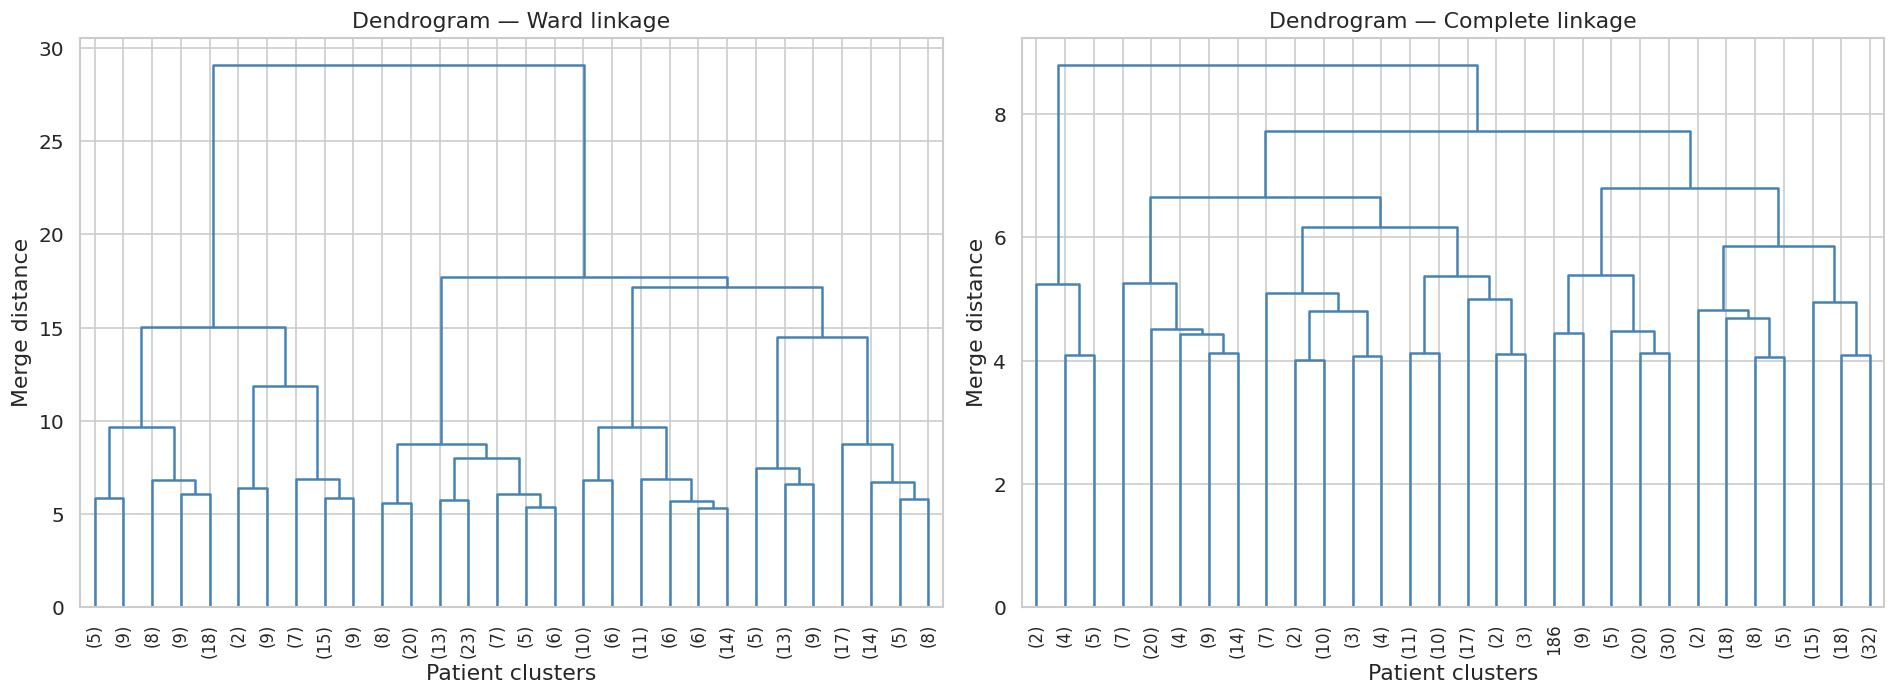

In [40]:
# drawing the dendogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ward dendrogram
dendrogram(linkage_ward,
           ax=axes[0],
           truncate_mode='lastp',
           p=30, # shows only last 30 merges for readability
           leaf_rotation=90,
           link_color_func=lambda k: 'steelblue')
axes[0].set_title('Dendrogram — Ward linkage')
axes[0].set_xlabel('Patient clusters')
axes[0].set_ylabel('Merge distance')


# Complete dendrogram
dendrogram(linkage_complete,
           ax=axes[1],
           truncate_mode='lastp',
           p=30, # shows only last 30 merges for readability
           leaf_rotation=90,
           link_color_func=lambda k: 'steelblue')
axes[1].set_title('Dendrogram — Complete linkage')
axes[1].set_xlabel('Patient clusters')
axes[1].set_ylabel('Merge distance')


plt.tight_layout()
plt.show()

- ward linkage: there is a large gap visible between the final merge (approx 29 height) and the previous merges (approx 17). This suggest there is 2 natural groups in the data. We select therefor a cut point that will be placed just below the height of 29
- Complete linkage:  The dendogram is more fragmented with smaller and more unform merge distances. This structure is less clear than ward. A cut aroubd heigh 7 also suggest 2 main groups although less clear than ward

** preliminary conclusions:
Both link methods seem to point toward 2 clusters (k=2) we will select Ward as the preferred dendogram from here on based on the clear separation of clusters and confirm the k quantitatively using silhoutte scores

# Choose a cut point on the dendrogram and justify your choice

In [41]:
# silhoutte scores for Ward
for k in [2, 3, 4]:
    labels = fcluster(linkage_ward, k, criterion='maxclust')
    score  = silhouette_score(X_cluster, labels)
    print(f'k={k} → silhouette score: {score:.4f}')

k=2 → silhouette score: 0.1821
k=3 → silhouette score: 0.0956
k=4 → silhouette score: 0.1039


Silhouette scores confirm k=2 is the optimal number of clusters so we can confidently select a cuting point between approx 29 and 17

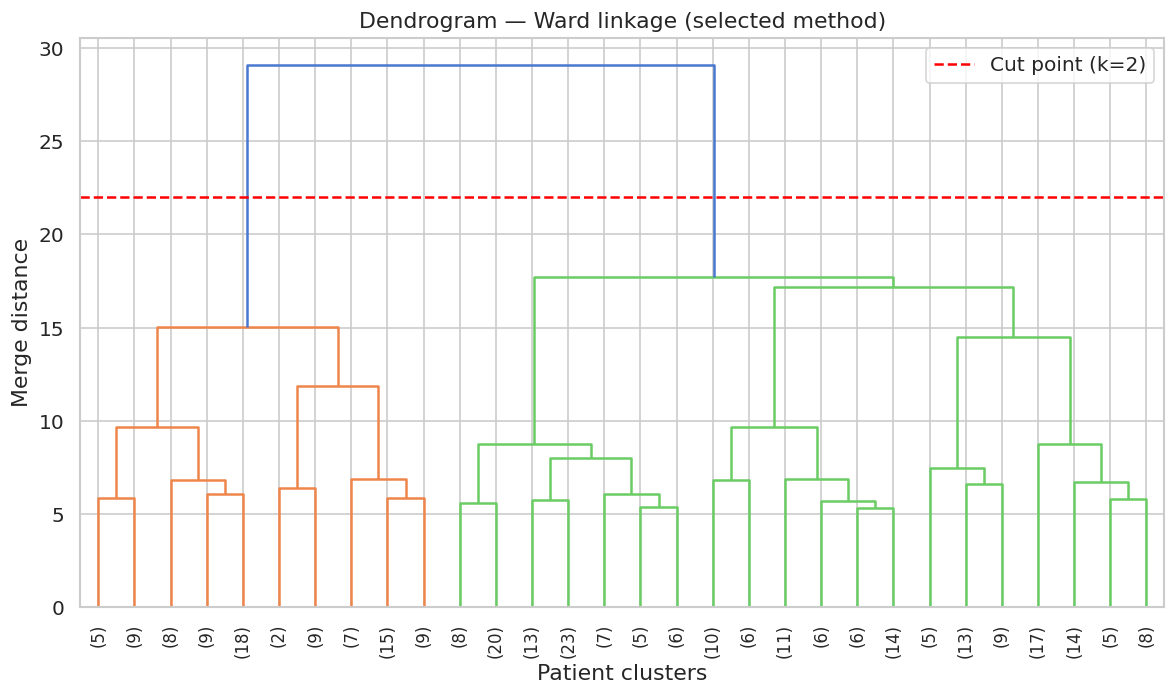

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))

dendrogram(linkage_ward,
           ax=ax,
           truncate_mode='lastp',
           p=30,
           leaf_rotation=90
           )

ax.set_title('Dendrogram — Ward linkage (selected method)')
ax.set_xlabel('Patient clusters')
ax.set_ylabel('Merge distance')

ax.axhline(y=22, color='red', linestyle='--', linewidth=1.5, label='Cut point (k=2)') # selecting a cut point at height 22
ax.legend()

plt.tight_layout()
plt.show()

# 5.3 Visualise the cluster assignments by projecting the data into PCA space (2D).

Report and interpret the cluster centres directly in the original feature space, which features are highest
or lowest for each group?.


assigning labels to patient based on the selected cutting point


In [46]:
# Cutting the Ward dendrogram at k=2
labels_ward = fcluster(linkage_ward, 2, criterion='maxclust')

# Check how many patients ended up in each cluster
unique, counts = np.unique(labels_ward, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} patients')

Cluster 1: 91 patients
Cluster 2: 206 patients


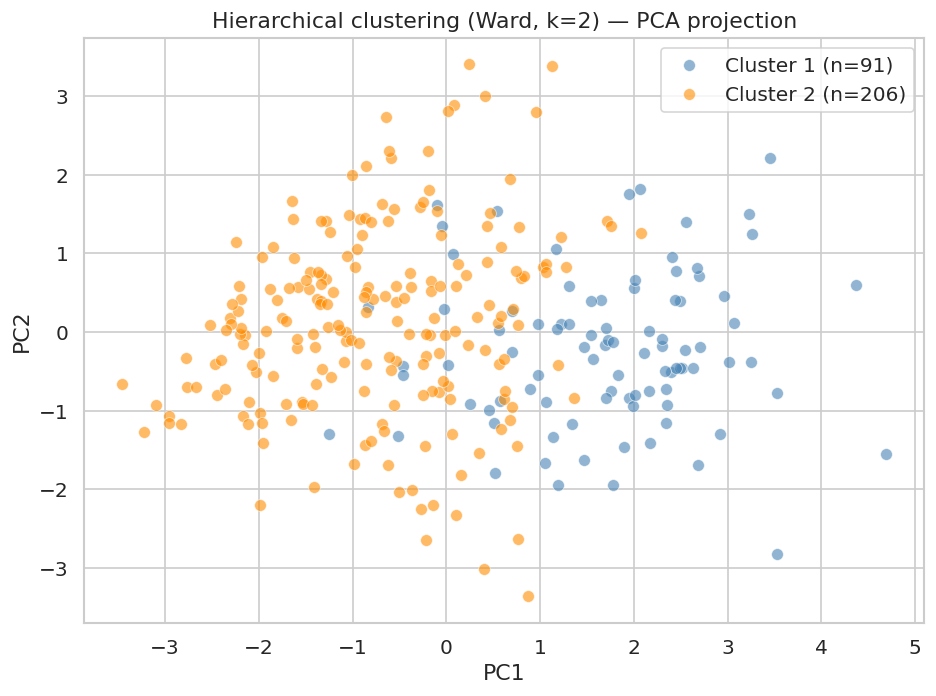

In [47]:
fig, ax = plt.subplots(figsize=(8, 6))

# Define colours for each cluster
colours = {1: 'steelblue', 2: 'darkorange'}
cluster_names = {1: f'Cluster 1 (n=91)', 2: f'Cluster 2 (n=206)'}

for cluster in [1, 2]:
    mask = labels_ward == cluster
    ax.scatter(X_pca_2d.loc[mask, 'PC1'],
               X_pca_2d.loc[mask, 'PC2'],
               c=colours[cluster],
               label=cluster_names[cluster],
               alpha=0.6,
               edgecolors='white',
               linewidths=0.5,
               s=50)

ax.set_title('Hierarchical clustering (Ward, k=2) — PCA projection')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

The 2 clusters show a clear separation along the PC1 axis (Cardiac stress axis)

In [48]:
# Add cluster labels to the original feature matrix
X_interpreted = X_cluster.copy()
X_interpreted['cluster'] = labels_ward

# Compute mean of each feature per cluster
cluster_profiles = X_interpreted.groupby('cluster').mean().round(3)
print(cluster_profiles.T)

cluster        1      2
age        0.591 -0.298
ca         0.685 -0.306
cp_2       0.033  0.223
cp_3       0.176  0.325
cp_4       0.725  0.369
exang      0.549  0.228
oldpeak    0.820 -0.369
restecg_0  0.374  0.549
restecg_2  0.582  0.451
sex        0.758  0.641
slope      0.655 -0.251
thal_3.0   0.297  0.665
thal_7.0   0.593  0.296
thalach   -1.019  0.434
trestbps   0.040 -0.064


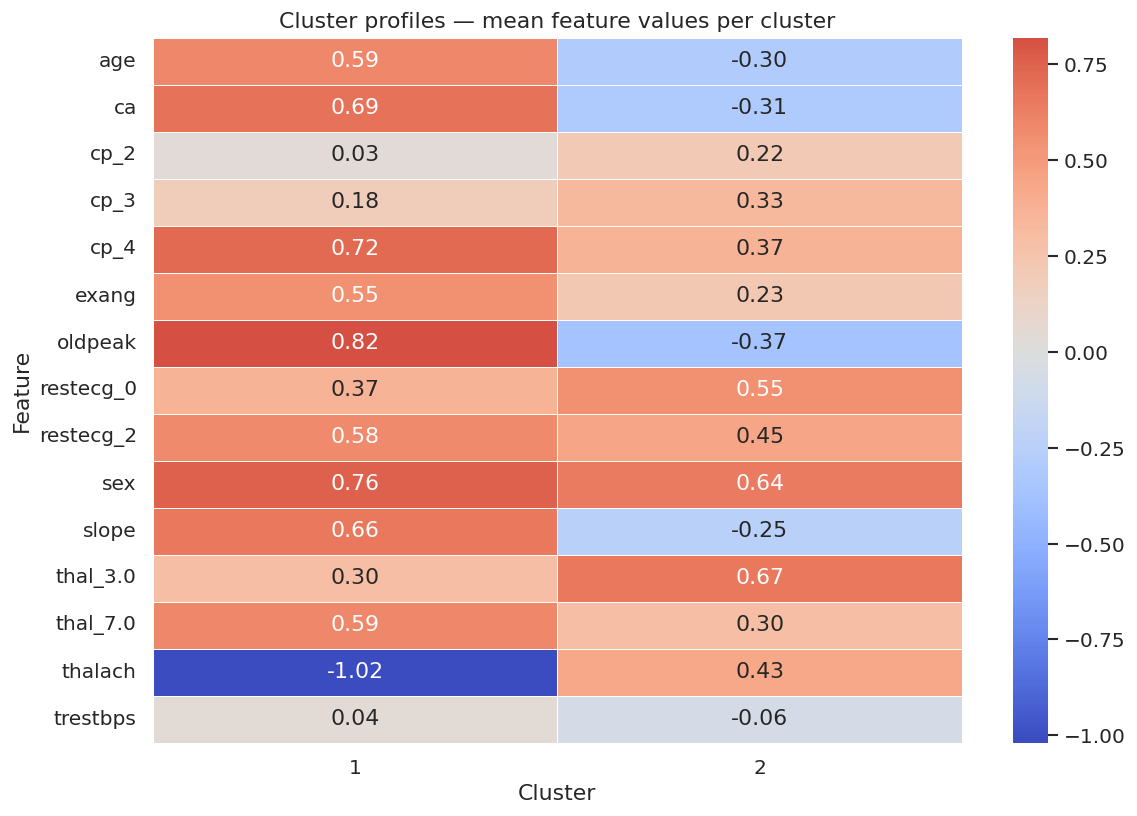

In [49]:
#plot heatmap for easier visualization
fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(cluster_profiles.T,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            ax=ax)

ax.set_title('Cluster profiles — mean feature values per cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.show()

# cluster interpretation
The heatmap shows the mean standardised value of each feature per cluster. As these are standardised values, 0 is the dataset average, any positive value is above the averga while any negative value is below the average on the dataset.

**Cluster 1 (n=91) - high cardiac risk profile** This cluster is characterized by patients that present signs of cardiac risk including
- Highet "oldpeak" +0.82: well above average ST depression induced by excercise, being an indicator of myocardial ischaemia.
- Lowest "thalach" -1.02: well below average maximum heart rate achieved,
  indicating poor cardiac response to exercise
- High "ca" +0.69: indicating more major vessels blocked
- High "cp_4" +0.72: more asymptomatic chest pain, paradoxically  associated
  with more severe disease
- High "thal_7.0" +0.59: more reversible defects in thallium scan, this indicats areas of reduced blood flow
- High "exang" +0.55: more exercise-induced angina
- Older patients on average: "age" +0.59

**Cluster 2 (n=206) — lower cardiac risk profile:** This cluster is characterized with patinets with lower signs of cardiac risk
- Highest "thalach" +0.43: above average maximum heart rate, indicating healthy cardiac response to exercise
- Lowest "oldpeak" -0.37: below average ST depression, a healthy sign
- High "thal_3.0" +0.67: more normal thallium scans
- Low "ca" -0.31: fewer blocked vessels
- Younger patients on average: "age" -0.30

**Summary:**

Cluster 1 captures a clinically coherent high-risk patient group characterized by poor exercise response, blocked vessels and abnormal cardiac scans.

Cluster 2 represents a lower-risk group with healthier cardiac indicators.



### 5.6 Structural comparison — hierarchical clustering vs K-Means and GMM

**1. No need to pre-specify k**
Hierarchical clustering does not require choosing the number of clusters before
running the algorithm. The full tree is built first, and k is decided afterwards
by inspecting the dendrogram. K-Means and GMM both require k to be specified
upfront, which means multiple runs are needed to find the optimal value.

**2. Deterministic algorithm**
Hierarchical clustering produces the same result every time — there is no
random initialisation. K-Means is sensitive to the random starting positions
of its centroids and can converge to different solutions on different runs.
GMM also depends on random initialisation of its parameters.

**3. No assumptions about cluster shape**
K-Means assumes clusters are spherical and equally sized — it minimises
distance to centroids. GMM assumes clusters follow a Gaussian distribution,
allowing elliptical shapes but still imposing a parametric form. Hierarchical
clustering makes no assumptions about cluster shape — it simply merges the
closest pairs at each step according to the chosen linkage criterion.

**4. Merges are irreversible**
Once two groups are merged in hierarchical clustering they cannot be separated
in later steps. This is a key limitation — an early incorrect merge propagates
through the entire tree. K-Means and GMM iteratively reassign points at every
step, correcting mistakes as they converge.

**5. Scalability**
Hierarchical clustering is computationally expensive — it scales as O(n²) or
worse with the number of patients. K-Means and GMM scale much better to large
datasets. For 297 patients this is not a problem, but it would be in a large
clinical database.

**6. Soft vs hard assignments**
GMM is the only method that produces soft assignments — each patient receives
a probability of belonging to each cluster rather than a definitive label.
Both K-Means and hierarchical clustering produce hard assignments only.

**Summary:** Hierarchical clustering offers the unique advantage of not requiring
k upfront and providing a full visual tree of patient relationships via the
dendrogram. However it is slower, cannot correct early merge mistakes, and
scales poorly. For this dataset with 297 patients it performed well, and the
dendrogram provided strong visual justification for k=2 that complements the
quantitative silhouette analysis.